In [1]:
import importlib
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import prism
import warnings
import copy
import logging

import imagematerials.buildings.constants as bld_const
import imagematerials.buildings.preprocessing.circular_economy_measures as ce_mod
import imagematerials.buildings.preprocessing.main as bld_main
from imagematerials.util import read_circular_economy_config, read_climate_policy_config
from imagematerials.buildings.preprocessing.population import compute_population
from imagematerials.concepts import create_region_graph
from imagematerials.constants import IMAGE_REGIONS

# Force reload so the kernel picks up latest code
importlib.reload(bld_const)
importlib.reload(ce_mod)
importlib.reload(bld_main)
from imagematerials.buildings.preprocessing.main import buildings_preprocessing

In [2]:
base_dir = Path("..", "data", "raw")
climate_dir = Path("..", "..", "data", "IMAGE_CircoMod", "SSP2")
climate_dir_narrow_act = Path("..", "..", "data", "IMAGE_CircoMod", "SSP2_narrow_act")
ce_dir_base = {
    "base": base_dir / "circular_economy_scenarios" / "base",
}
ce_dir_narrow_act = {
    "base": base_dir / "circular_economy_scenarios" / "base",
    "narrow_activity": base_dir / "circular_economy_scenarios" / "narrow_activity",
}

climate_config = read_climate_policy_config(climate_dir)
climate_config_narrow_act = read_climate_policy_config(climate_dir_narrow_act)

logging.basicConfig(
    level=logging.DEBUG,
    format='%(name)s - %(levelname)s - %(message)s',
    force=True
)

comm_types = ["Office", "Retail+", "Hotels+", "Govt+"]
results = {}
prep_store = {}  # full prep_data dicts for model runs
ce_cfg = read_circular_economy_config(ce_dir_narrow_act)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")

    # CE = None (baseline)
    from imagematerials.preprocessing import get_preprocessing_data
    prep_none = get_preprocessing_data("buildings", Path("..", "data", "raw"), climate_dir, None)
    results["none"] = prep_none.prep_data["stocks"].sel(Type=comm_types).sum("Type")

    # CE = base
    prep_base = buildings_preprocessing(base_dir, climate_config, read_circular_economy_config(ce_dir_base))
    results["base"] = prep_base["stocks"].sel(Type=comm_types).sum("Type")
    prep_store["base"] = prep_base

    # CE = narrow_activity with convergence mode
    ce_cfg_conv = copy.deepcopy(ce_cfg)
    ce_cfg_conv["narrow_activity"]["buildings"]["commercial_ce_mode"] = "convergence"
    print("--- Running mode: convergence ---")
    prep_conv = buildings_preprocessing(base_dir, climate_config_narrow_act, ce_cfg_conv)
    results["ce"] = prep_conv["stocks"].sel(Type=comm_types).sum("Type")
    prep_store["ce"] = prep_conv

    # CE = narrow_activity with relative-only mode (no convergence)
    ce_cfg_rel = copy.deepcopy(ce_cfg)
    ce_cfg_rel["narrow_activity"]["buildings"]["commercial_ce_mode"] = "relative"
    print("--- Running mode: relative only ---")
    prep_rel = buildings_preprocessing(base_dir, climate_config_narrow_act, ce_cfg_rel)
    results["relative"] = prep_rel["stocks"].sel(Type=comm_types).sum("Type")
    prep_store["relative"] = prep_rel

# --- Compute population (rebroadcast to named IMAGE regions) ---
image_dir = Path(climate_config["config_file_path"])
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    population = compute_population(image_dir, base_dir)

knowledge_graph_region = create_region_graph()
population = knowledge_graph_region.rebroadcast_xarray(
    population, output_coords=IMAGE_REGIONS, dim="Region")
pop_total = population.sel(Area="Total")

# --- Shared plot helpers ---
all_regions = list(results["ce"].coords["Region"].values)
cmap = plt.cm.get_cmap("tab20", len(all_regions))
region_colors = {reg: cmap(i) for i, reg in enumerate(all_regions)}

pint.util - WARNING - Redefining 'percent' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining '%' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)


FUNCTION CALLED
ce keys: []
ce_scen = None


root - DEBUG - implemented 'base' for Commercial Buildings
root - DEBUG - implemented 'base' for Residential Buildings


FUNCTION CALLED
ce keys: ['base']
ce_scen = None
--- Running mode: convergence ---


root - DEBUG - implemented 'base' for Commercial Buildings
root - INFO - Commercial CE: low regions (< 5.0 m²/cap in 2020, no relative reduction): ['RCAM', 'RSAM', 'NAF', 'WAF', 'EAF', 'UKR', 'STAN', 'INDIA', 'SEAS', 'INDO', 'RSAS', 'RSAF']


...

root - INFO - CE phase 2 — above cap at 2060 (linear decline to cap by 2100): ['CAN', 'WEU', 'CEU', 'TUR', 'ME', 'KOR', 'USA', 'CHN', 'JAP', 'OCE', 'BRA']
root - INFO - CE phase 2 — low regions (follow baseline, linear cap at 14.0 by 2100): ['RCAM', 'RSAM', 'NAF', 'WAF', 'EAF', 'UKR', 'STAN', 'INDIA', 'SEAS', 'INDO', 'RSAS', 'RSAF']
root - INFO - CE phase 2 — mid-range (linear transition to baseline, capped at 14.0 by 2100): ['SAF', 'RUS', 'MEX']
root - DEBUG - implemented 'narrow_activity' for Commercial Buildings (relative + convergence)
root - DEBUG - implemented 'base' for Residential Buildings


--- Running mode: relative only ---


root - DEBUG - implemented 'base' for Commercial Buildings


FUNCTION CALLED
ce keys: ['base', 'narrow_activity']
ce_scen = None
mode = relative


root - DEBUG - implemented 'narrow_activity' for Commercial Buildings (relative only)
root - DEBUG - implemented 'base' for Residential Buildings
C:\Users\5982758\AppData\Local\Temp\ipykernel_25680\1654555520.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(all_regions))


In [3]:
# --- Region classification and per-capita summary ---
cap_value = ce_cfg["narrow_activity"]["buildings"]["convergence_cap"]
low_threshold = ce_cfg["narrow_activity"]["buildings"].get("low_threshold", 5.0)
target_year = ce_cfg["narrow_activity"]["buildings"]["target_year"]
convergence_year_end = ce_cfg["narrow_activity"]["buildings"].get("convergence_year_end", 2100)

# Per-capita: dequantify first to avoid pint DimensionalityError
def to_float_pc(stock):
    s = stock.pint.dequantify() if prism.U_(stock) is not None else stock
    p = pop_total.pint.dequantify() if prism.U_(pop_total) is not None else pop_total
    return s / p

pc_ce = to_float_pc(results["ce"])
pc_baseline = to_float_pc(results["none"])

# Classify regions by 2020 baseline per-capita
pc_2020 = pc_baseline.sel(Time=2020)
low_regs = [r for r in all_regions if float(pc_2020.sel(Region=r)) < low_threshold]
eligible_regs = [r for r in all_regions if float(pc_2020.sel(Region=r)) >= low_threshold]

# At target year, classify eligible regions
pc_ce_target = {r: float(pc_ce.sel(Region=r, Time=target_year)) for r in all_regions}
above_cap = [r for r in eligible_regs if pc_ce_target[r] > cap_value]
mid_range = [r for r in eligible_regs if pc_ce_target[r] <= cap_value]

# --- Build summary table ---
rows = []
for r in sorted(above_cap):
    rows.append({
        "Region": r,
        "Category": f"(a) above cap at {target_year}",
        f"2020 m²/cap": round(float(pc_2020.sel(Region=r)), 1),
        f"{target_year} m²/cap (CE)": round(pc_ce_target[r], 1),
        f"2100 m²/cap (CE)": round(float(pc_ce.sel(Region=r, Time=2100)), 1),
        f"2100 m²/cap (baseline)": round(float(to_float_pc(results["none"]).sel(Region=r, Time=2100)), 1),
    })
for r in sorted(low_regs):
    rows.append({
        "Region": r,
        "Category": f"(b) low < {low_threshold} m²/cap in 2020",
        f"2020 m²/cap": round(float(pc_2020.sel(Region=r)), 1),
        f"{target_year} m²/cap (CE)": round(pc_ce_target[r], 1),
        f"2100 m²/cap (CE)": round(float(pc_ce.sel(Region=r, Time=2100)), 1),
        f"2100 m²/cap (baseline)": round(float(to_float_pc(results["none"]).sel(Region=r, Time=2100)), 1),
    })
for r in sorted(mid_range):
    rows.append({
        "Region": r,
        "Category": "(c) mid-range",
        f"2020 m²/cap": round(float(pc_2020.sel(Region=r)), 1),
        f"{target_year} m²/cap (CE)": round(pc_ce_target[r], 1),
        f"2100 m²/cap (CE)": round(float(pc_ce.sel(Region=r, Time=2100)), 1),
        f"2100 m²/cap (baseline)": round(float(to_float_pc(results["none"]).sel(Region=r, Time=2100)), 1),
    })

df_summary = pd.DataFrame(rows).set_index("Region")

print(f"Cap = {cap_value} m²/cap | Low threshold = {low_threshold} m²/cap | "
      f"Target year = {target_year} | Convergence end = {convergence_year_end}\n")
display(df_summary)
print("\n--- Copy-friendly plain text ---")
print(df_summary.to_string())

Cap = 14.0 m²/cap | Low threshold = 5.0 m²/cap | Target year = 2060 | Convergence end = 2100



,Category,2020 m²/cap,2060 m²/cap (CE),2100 m²/cap (CE),2100 m²/cap (baseline)
Region,,,,,
BRA,(a) above cap at 2060,5.8,14.7,14.0,25.4
CAN,(a) above cap at 2060,20.0,16.4,14.0,25.6
CEU,(a) above cap at 2060,9.5,17.5,14.0,24.5
CHN,(a) above cap at 2060,5.4,16.3,14.0,25.1
JAP,(a) above cap at 2060,17.3,18.9,14.0,25.3
KOR,(a) above cap at 2060,11.4,16.6,14.0,24.6
ME,(a) above cap at 2060,7.8,14.6,14.0,24.8
OCE,(a) above cap at 2060,17.3,14.8,14.0,25.5
TUR,(a) above cap at 2060,7.9,16.4,14.0,24.4



--- Copy-friendly plain text ---
                            Category  2020 m²/cap  2060 m²/cap (CE)  2100 m²/cap (CE)  2100 m²/cap (baseline)
Region                                                                                                       
BRA            (a) above cap at 2060          5.8              14.7              14.0                    25.4
CAN            (a) above cap at 2060         20.0              16.4              14.0                    25.6
CEU            (a) above cap at 2060          9.5              17.5              14.0                    24.5
CHN            (a) above cap at 2060          5.4              16.3              14.0                    25.1
JAP            (a) above cap at 2060         17.3              18.9              14.0                    25.3
KOR            (a) above cap at 2060         11.4              16.6              14.0                    24.6
ME             (a) above cap at 2060          7.8              14.6              14.0 

matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Bold.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmex10.ttf', name='cmex10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
matplotlib.font_manager - 

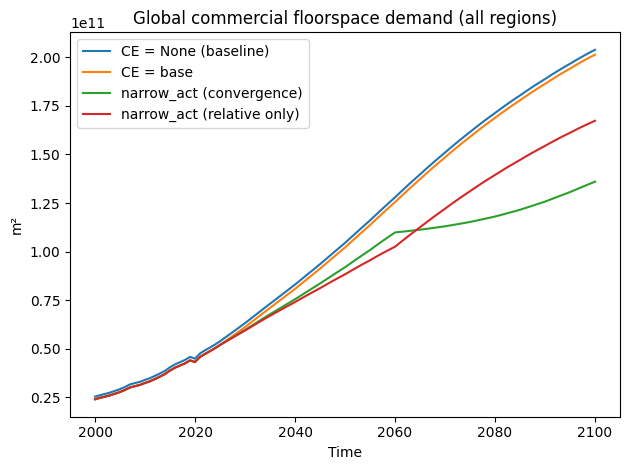

In [4]:
# Global commercial floorspace stock: all scenarios
scenario_labels = {"none": "CE = None (baseline)", "base": "CE = base",
                   "ce": "narrow_act (convergence)",
                   "relative": "narrow_act (relative only)"}

for key, label in scenario_labels.items():
    total = results[key].sum("Region").loc[2000:]
    if prism.U_(total) is not None:
        total = total.pint.to("m**2")
    total.plot(label=label)

plt.legend()
plt.ylabel("m²")
plt.title("Global commercial floorspace demand (all regions)")
plt.tight_layout()
plt.show()

matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=7.0.
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Bold.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmex10.ttf', name='cmex10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBol.ttf', name='STIXGeneral'

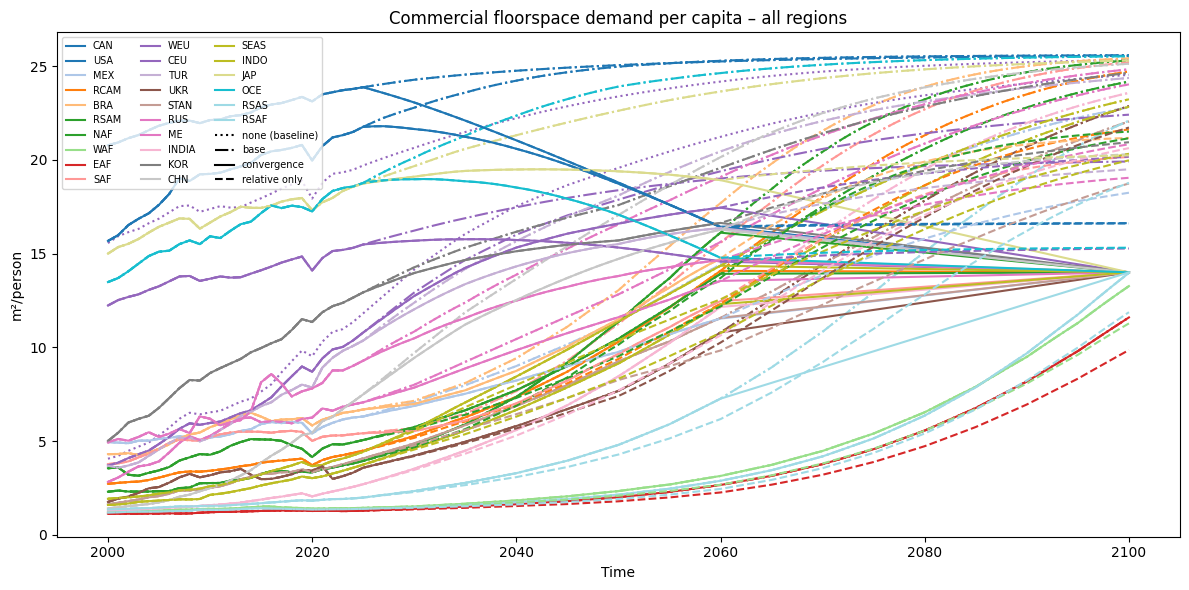

In [5]:
# --- Per-capita comparison: all regions ---
fig, ax = plt.subplots(figsize=(12, 6))

scen_styles_pc = {"none": ":", "base": "-.", "ce": "-", "relative": "--"}
scen_legend_pc = {"none": "none (baseline)", "base": "base",
                  "ce": "convergence", "relative": "relative only"}

for key, stocks in results.items():
    ls = scen_styles_pc.get(key, "-")
    for reg in all_regions:
        series = stocks.sel(Region=reg).loc[2000:]
        pop_reg = pop_total.sel(Region=reg).loc[2000:]
        # Dequantify to avoid pint DimensionalityError
        s = series.pint.dequantify() if prism.U_(series) is not None else series
        p = pop_reg.pint.dequantify() if prism.U_(pop_reg) is not None else pop_reg
        pc = s / p
        pc.plot(ax=ax, linestyle=ls, color=region_colors[reg])

handles = [Line2D([0], [0], color=region_colors[r], lw=1.5, label=r) for r in all_regions]
for key, ls in scen_styles_pc.items():
    handles.append(Line2D([0], [0], color="black", lw=1.5, linestyle=ls,
                          label=scen_legend_pc[key]))
ax.legend(handles=handles, fontsize=7, ncol=3, loc="upper left")
ax.set_title("Commercial floorspace demand per capita – all regions")
ax.set_ylabel("m²/person")

plt.tight_layout()
plt.show()

matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=8.0.
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Bold.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmex10.ttf', name='cmex10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\5982758\\AppData\\Local\\anaconda3\\envs\\materials_dev_26\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBol.ttf', name='STIXGeneral'

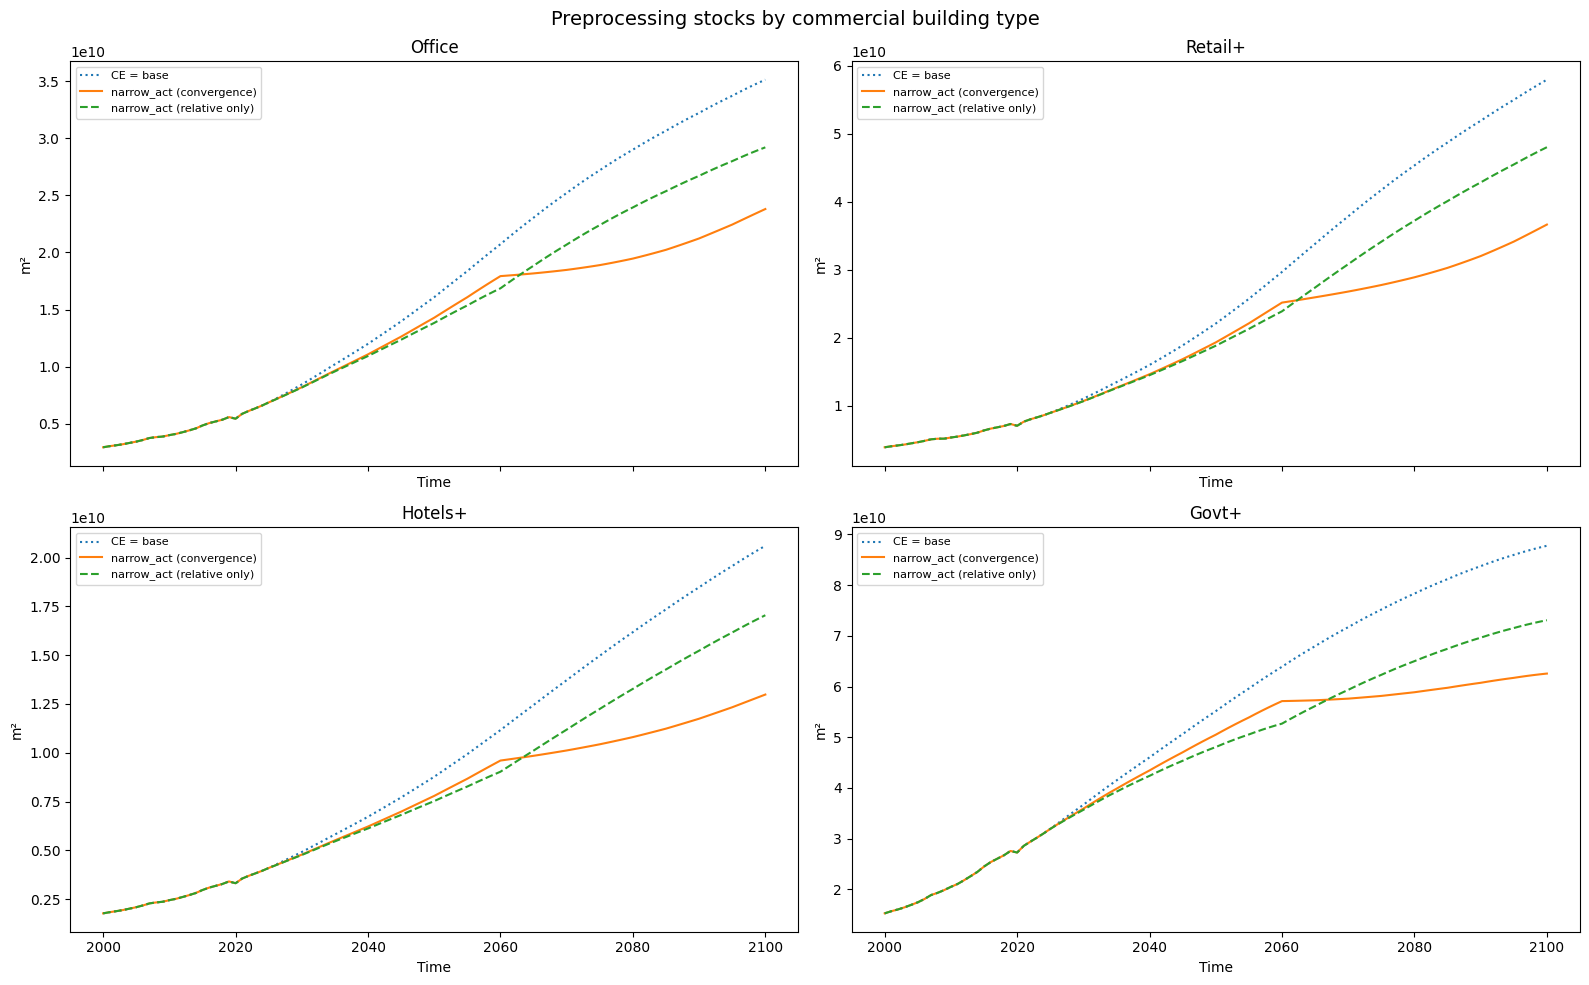

In [6]:

# --- Preprocessing stocks per commercial building type ---
comm_types_plot = ["Office", "Retail+", "Hotels+", "Govt+"]
scen_labels = {"base": "CE = base", "ce": "narrow_act (convergence)",
               "relative": "narrow_act (relative only)"}
scen_styles = {"base": ":", "ce": "-", "relative": "--"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes_flat = axes.flatten()

for i, btype in enumerate(comm_types_plot):
    ax = axes_flat[i]
    for scen, label in scen_labels.items():
        stock = prep_store[scen]["stocks"].sel(Type=btype).sum("Region").loc[2000:]
        if prism.U_(stock) is not None:
            stock = stock.pint.to("m**2")
        stock.plot(ax=ax, label=label, linestyle=scen_styles[scen])
    ax.set_title(btype)
    ax.set_ylabel("m²")
    ax.legend(fontsize=8)

fig.suptitle("Preprocessing stocks by commercial building type", fontsize=14)
plt.tight_layout()
plt.show()


In [8]:


# --- Run the full model (with lifetime dynamics) for base, relative, convergence ---
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import GenericStocks

complete_timeline = prism.Timeline(1971, 2100, 1)
simulation_timeline = prism.Timeline(1971, 2100, 1)

model_results = {}  # key -> model.buildings dict

for scen, prep_data in prep_store.items():
    sector = Sector("buildings", prep_data)
    model = ModelFactory(
        [sector], complete_timeline
    ).add(GenericStocks, ["buildings"]).finish()

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)

    model_results[scen] = dict(model.buildings)
    print(f"Finished model run: {scen}")

print("Available keys:", list(model_results["base"].keys()))




pint.util - WARNING - Redefining 'person' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'persons' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'people' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'meter' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'm' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'share' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'ratio' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'fraction' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'US_Dollar' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
pint.util - WARNING - Redefining 'USD' (<class 'pint.delegates.txt

Finished model run: base
Finished model run: ce
Finished model run: relative
Available keys: ['stocks', 'lifetimes', 'material_intensities', 'knowledge_graph', 'set_unit_flexible', 'outflow_by_cohort', 'inflow', 'stock_by_cohort']


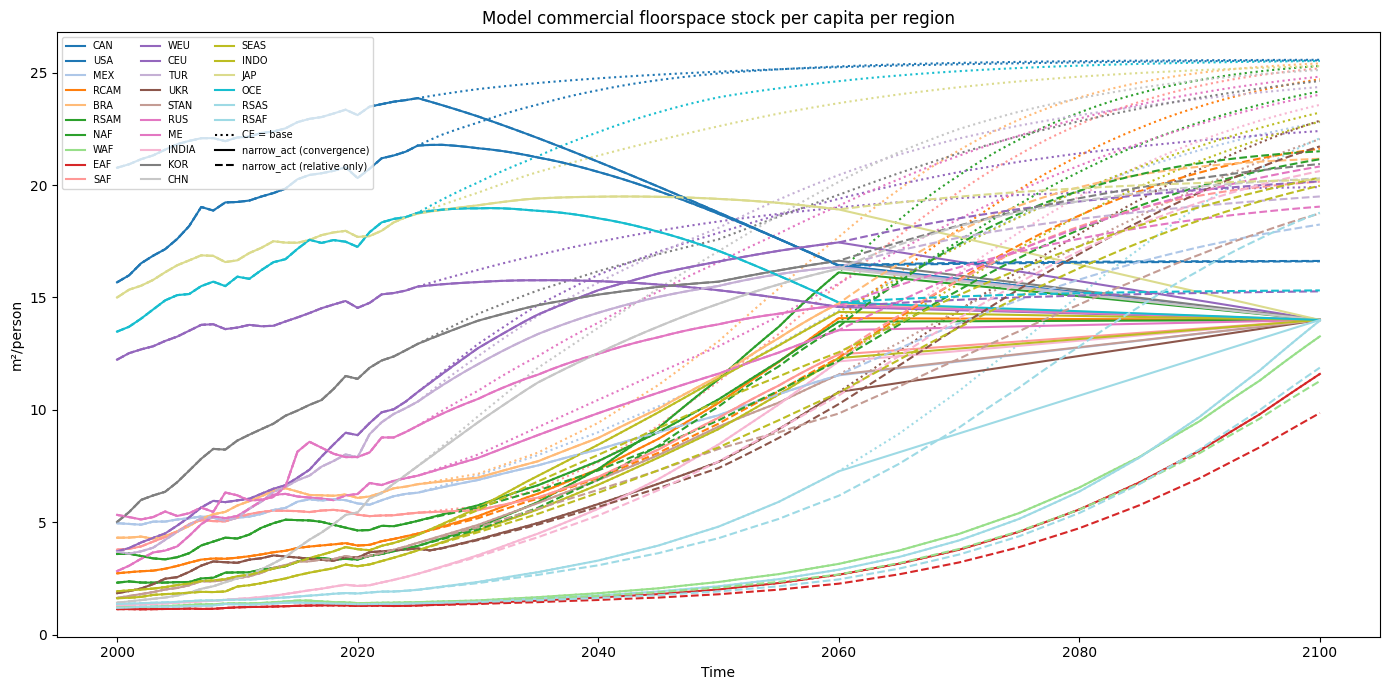

In [9]:

# --- Model stocks per capita per region (with lifetime dynamics, from stock_by_cohort) ---
fig, ax = plt.subplots(figsize=(14, 7))

for scen, label in scen_labels.items():
    ls = scen_styles[scen]
    stock_all = model_results[scen]["stock_by_cohort"].sum("Cohort").sel(Type=comm_types_plot).sum("Type")
    for reg in all_regions:
        series = stock_all.sel(Region=reg).loc[2000:]
        if prism.U_(series) is not None:
            series = series.pint.dequantify()
        pop_reg = pop_total.sel(Region=reg).loc[2000:]
        if prism.U_(pop_reg) is not None:
            pop_reg = pop_reg.pint.dequantify()
        pc = series / pop_reg
        pc.plot(ax=ax, linestyle=ls, color=region_colors[reg])

handles = [Line2D([0], [0], color=region_colors[r], lw=1.5, label=r) for r in all_regions]
for scen, ls in scen_styles.items():
    handles.append(Line2D([0], [0], color="black", lw=1.5, linestyle=ls,
                          label=scen_labels[scen]))
ax.legend(handles=handles, fontsize=7, ncol=3, loc="upper left")
ax.set_title("Model commercial floorspace stock per capita per region")
ax.set_ylabel("m²/person")

plt.tight_layout()
plt.show()


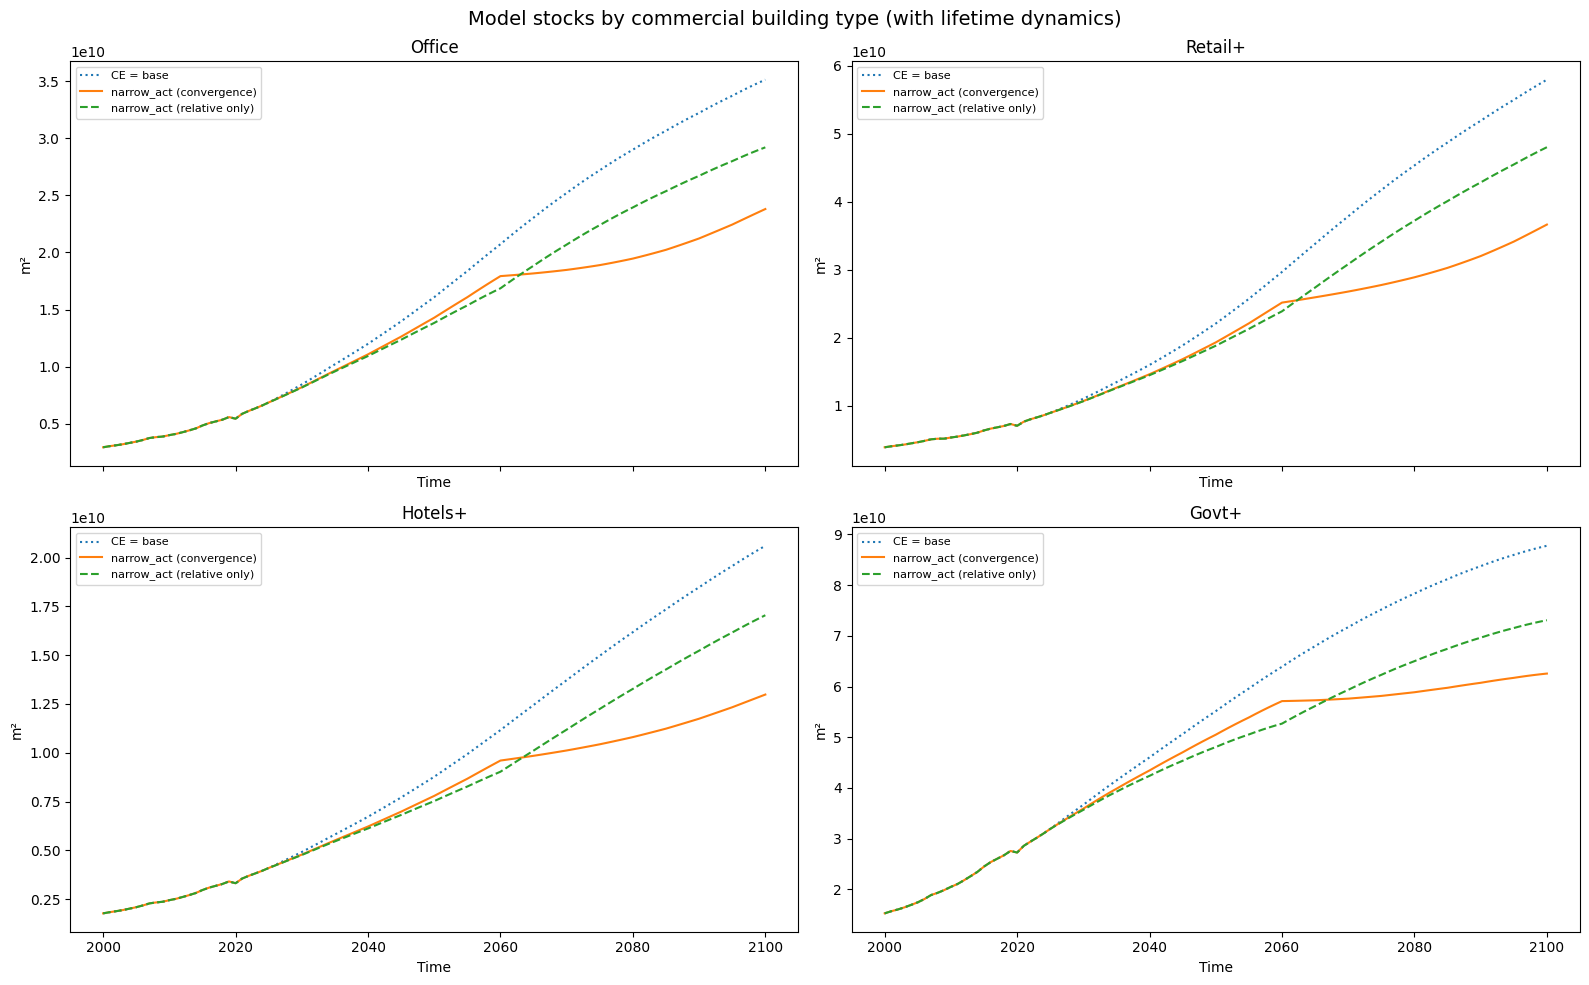

In [10]:
# --- Model stocks per commercial building type (with lifetime dynamics) ---
comm_types_plot = ["Office", "Retail+", "Hotels+", "Govt+"]
scen_labels = {"base": "CE = base", "ce": "narrow_act (convergence)",
               "relative": "narrow_act (relative only)"}
scen_styles = {"base": ":", "ce": "-", "relative": "--"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes_flat = axes.flatten()

for i, btype in enumerate(comm_types_plot):
    ax = axes_flat[i]
    for scen, label in scen_labels.items():
        stock = model_results[scen]["stocks"].sel(Type=btype).sum("Region").loc[2000:]
        if prism.U_(stock) is not None:
            stock = stock.pint.to("m**2")
        stock.plot(ax=ax, label=label, linestyle=scen_styles[scen])
    ax.set_title(btype)
    ax.set_ylabel("m²")
    ax.legend(fontsize=8)

fig.suptitle("Model stocks by commercial building type (with lifetime dynamics)", fontsize=14)
plt.tight_layout()
plt.show()

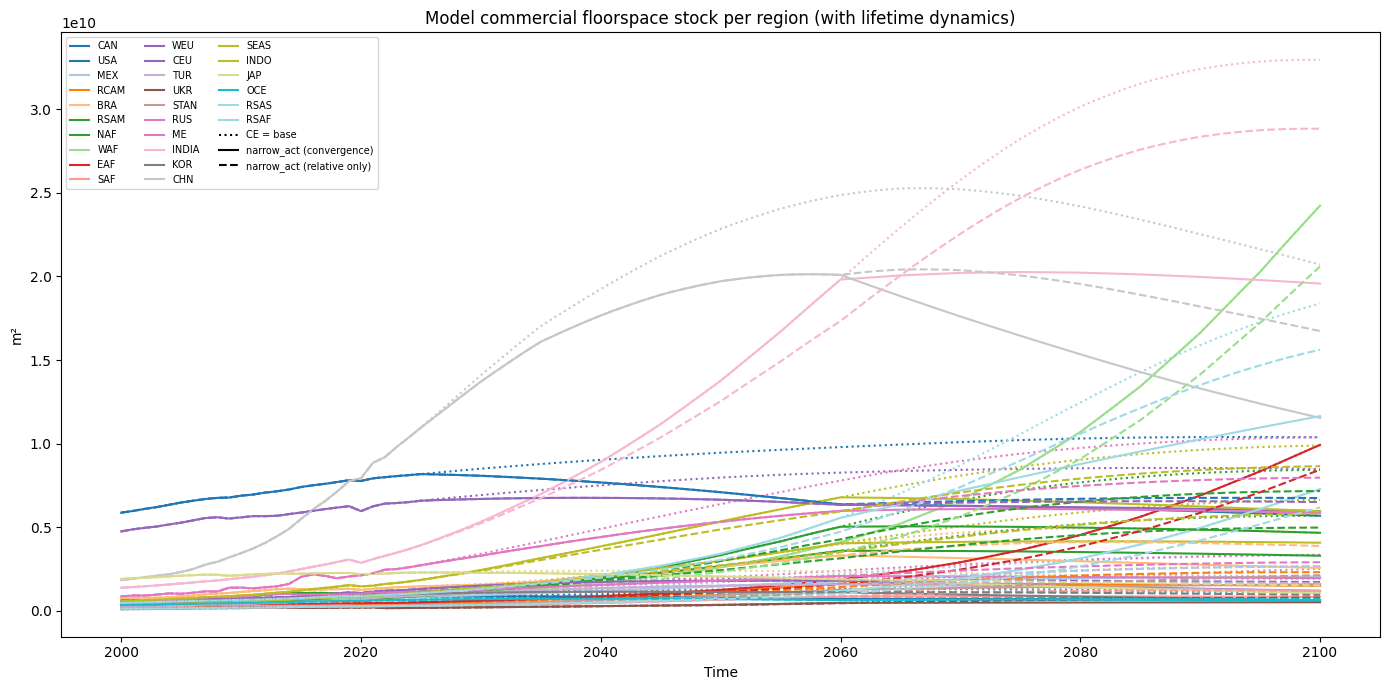

In [11]:
# --- Model stocks per region (with lifetime dynamics), all commercial types summed ---
fig, ax = plt.subplots(figsize=(14, 7))

for scen, label in scen_labels.items():
    ls = scen_styles[scen]
    stock_all = model_results[scen]["stocks"].sel(Type=comm_types_plot).sum("Type")
    for reg in all_regions:
        series = stock_all.sel(Region=reg).loc[2000:]
        if prism.U_(series) is not None:
            series = series.pint.to("m**2")
        series.plot(ax=ax, linestyle=ls, color=region_colors[reg])

# Legend: one entry per region + one per scenario linestyle
handles = [Line2D([0], [0], color=region_colors[r], lw=1.5, label=r) for r in all_regions]
for scen, ls in scen_styles.items():
    handles.append(Line2D([0], [0], color="black", lw=1.5, linestyle=ls,
                          label=scen_labels[scen]))
ax.legend(handles=handles, fontsize=7, ncol=3, loc="upper left")
ax.set_title("Model commercial floorspace stock per region (with lifetime dynamics)")
ax.set_ylabel("m²")

plt.tight_layout()
plt.show()

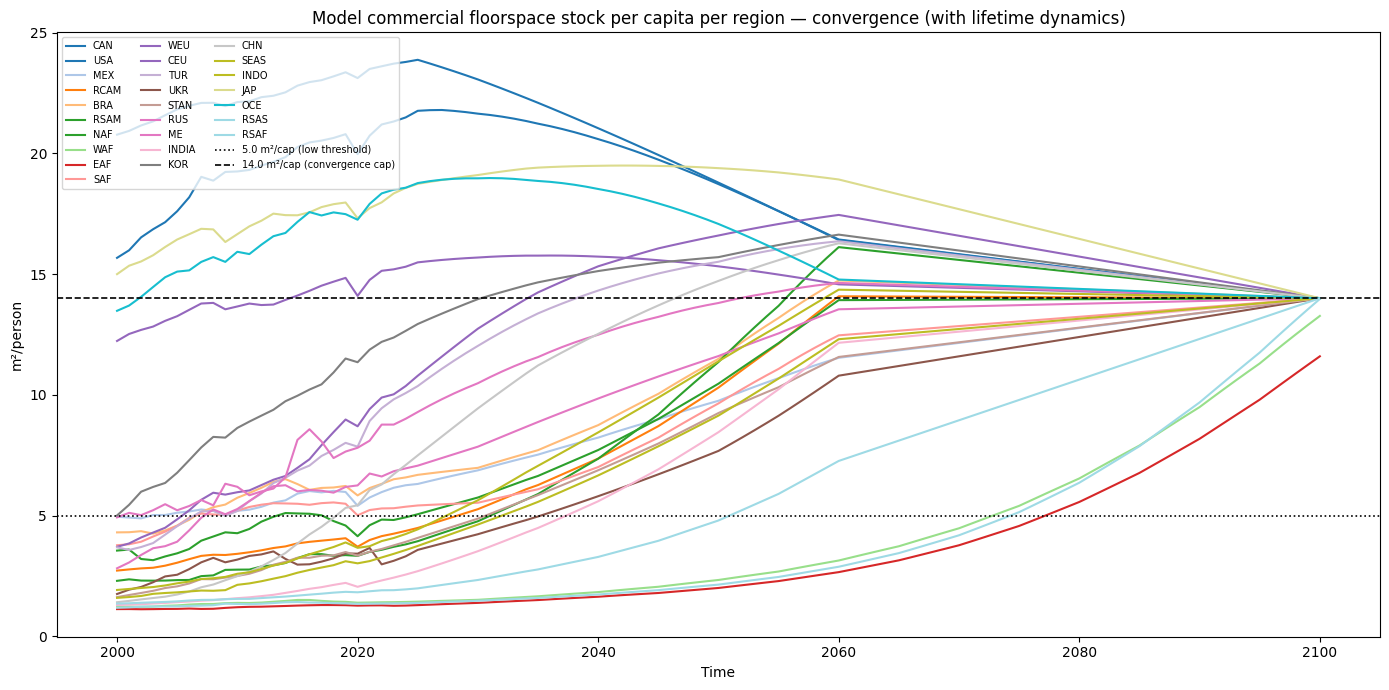

In [12]:
# --- Model stocks per capita per region — convergence scenario only ---
fig, ax = plt.subplots(figsize=(14, 7))

stock_all_ce = model_results["ce"]["stocks"].sel(Type=comm_types_plot).sum("Type")
for reg in all_regions:
    series = stock_all_ce.sel(Region=reg).loc[2000:]
    if prism.U_(series) is not None:
        series = series.pint.dequantify()
    pop_reg = pop_total.sel(Region=reg).loc[2000:]
    if prism.U_(pop_reg) is not None:
        pop_reg = pop_reg.pint.dequantify()
    pc = series / pop_reg
    pc.plot(ax=ax, color=region_colors[reg], label=reg)

ax.axhline(low_threshold, color="black", linestyle=":", linewidth=1.2, label=f"{low_threshold} m²/cap (low threshold)")
ax.axhline(cap_value, color="black", linestyle="--", linewidth=1.2, label=f"{cap_value} m²/cap (convergence cap)")

handles = [Line2D([0], [0], color=region_colors[r], lw=1.5, label=r) for r in all_regions]
handles.append(Line2D([0], [0], color="black", lw=1.2, linestyle=":", label=f"{low_threshold} m²/cap (low threshold)"))
handles.append(Line2D([0], [0], color="black", lw=1.2, linestyle="--", label=f"{cap_value} m²/cap (convergence cap)"))
ax.legend(handles=handles, fontsize=7, ncol=3, loc="upper left")
ax.set_title("Model commercial floorspace stock per capita per region — convergence (with lifetime dynamics)")
ax.set_ylabel("m²/person")

plt.tight_layout()
plt.show()

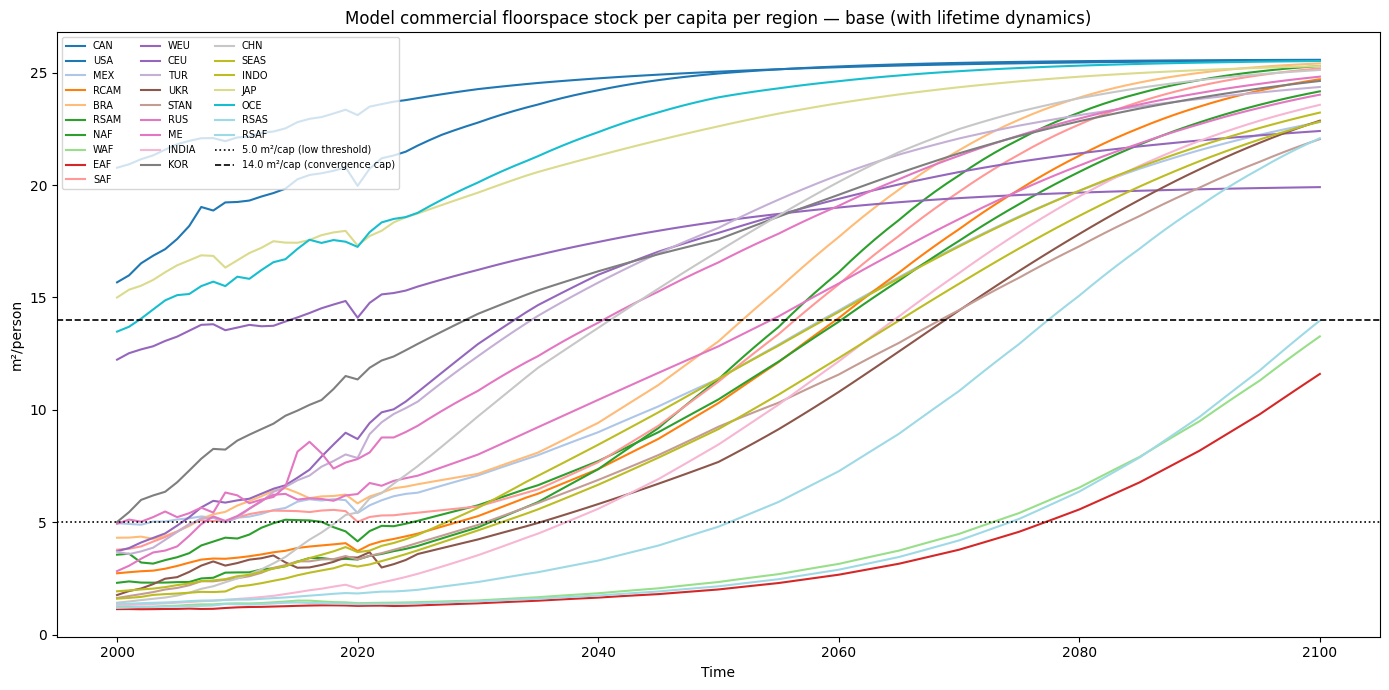

In [13]:
# --- Model stocks per capita per region — base scenario only ---
fig, ax = plt.subplots(figsize=(14, 7))

stock_all_base = model_results["base"]["stocks"].sel(Type=comm_types_plot).sum("Type")
for reg in all_regions:
    series = stock_all_base.sel(Region=reg).loc[2000:]
    if prism.U_(series) is not None:
        series = series.pint.dequantify()
    pop_reg = pop_total.sel(Region=reg).loc[2000:]
    if prism.U_(pop_reg) is not None:
        pop_reg = pop_reg.pint.dequantify()
    pc = series / pop_reg
    pc.plot(ax=ax, color=region_colors[reg], label=reg)

ax.axhline(low_threshold, color="black", linestyle=":", linewidth=1.2)
ax.axhline(cap_value, color="black", linestyle="--", linewidth=1.2)

handles = [Line2D([0], [0], color=region_colors[r], lw=1.5, label=r) for r in all_regions]
handles.append(Line2D([0], [0], color="black", lw=1.2, linestyle=":", label=f"{low_threshold} m²/cap (low threshold)"))
handles.append(Line2D([0], [0], color="black", lw=1.2, linestyle="--", label=f"{cap_value} m²/cap (convergence cap)"))
ax.legend(handles=handles, fontsize=7, ncol=3, loc="upper left")
ax.set_title("Model commercial floorspace stock per capita per region — base (with lifetime dynamics)")
ax.set_ylabel("m²/person")

plt.tight_layout()
plt.show()

In [ ]:

# --- Region classification and per-capita summary (from stock_by_cohort, after lifetime dynamics) ---
def model_pc(scen):
    """Per-capita from actual modelled stock (stock_by_cohort)."""
    stock = model_results[scen]["stock_by_cohort"].sum("Cohort").sel(Type=comm_types_plot).sum("Type")
    s = stock.pint.dequantify() if prism.U_(stock) is not None else stock
    p = pop_total.pint.dequantify() if prism.U_(pop_total) is not None else pop_total
    return s / p

mpc_ce   = model_pc("ce")
mpc_base = model_pc("base")

rows_model = []
for category, regions in [
    (f"(a) above cap at {target_year}", sorted(above_cap)),
    (f"(b) low < {low_threshold} m²/cap in 2020", sorted(low_regs)),
    ("(c) mid-range", sorted(mid_range)),
]:
    for r in regions:
        rows_model.append({
            "Region": r,
            "Category": category,
            "2020 m²/cap (CE)":              round(float(mpc_base.sel(Region=r, Time=2020)), 1),
            f"{target_year} m²/cap (CE)":    round(float(mpc_ce.sel(Region=r, Time=target_year)), 1),
            "2100 m²/cap (CE)":              round(float(mpc_ce.sel(Region=r, Time=2100)), 1),
            "2100 m²/cap (base)":            round(float(mpc_base.sel(Region=r, Time=2100)), 1),
        })

df_model = pd.DataFrame(rows_model).set_index("Region")

print(f"Cap = {cap_value} m²/cap | Low threshold = {low_threshold} m²/cap | "
      f"Target year = {target_year} | Convergence end = {convergence_year_end}\n")
print("Per-capita floorspace from stock_by_cohort (lifetime dynamics included)\n")
display(df_model)
print("\n--- Copy-friendly plain text ---")
print(df_model.to_string())


In [ ]:
model_results.keys()

# Exploring commercial floorspace intermediate data (CE = None)

Step through the individual functions behind `get_image_floorspace` to inspect
`service_value_added`, `commercial_m2_cap_sum`, and `commercial_m2_cap`.

In [ ]:
# --- Plot service_value_added for a selection of regions ---
fig, ax = plt.subplots(figsize=(12, 5))
sample_regions = [1, 2, 3, 5, 11, 18]  # a handful of IMAGE regions
for reg in sample_regions:
    if reg in service_value_added.columns:
        service_value_added[reg].plot(ax=ax, label=f"Region {reg}")
ax.set_title("Service Value Added per capita (inflation-adjusted)")
ax.set_ylabel("2016 US$/cap")
ax.set_xlabel("Year")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()